# Dự án Iris – Phân loại 3 loài hoa


## 1. Định nghĩa vấn đề
- **Bài toán**: phân loại đa lớp (3 lớp): *Iris-setosa*, *Iris-versicolor*, *Iris-virginica*.
- **Đầu vào**: 4 số đo (cm) – `sepal-length`, `sepal-width`, `petal-length`, `petal-width`. **Đầu ra**: loài hoa.
- **Dữ liệu**: 150 mẫu, cân bằng 50/50/50, **không có header** (nên phải tự đặt tên cột).
- **Thước đo**: Accuracy (phù hợp vì các lớp cân bằng) + confusion matrix.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
SEED = 7; sns.set_theme(style="whitegrid")

ROOT = next(d for d in [".", "ex01_iris_classification", "iris_classification/ex01_iris_classification"] if os.path.exists(f"{d}/data/iris.csv"))
names = ["sepal-length","sepal-width","petal-length","petal-width","class"]
df = pd.read_csv(f"{ROOT}/data/iris.csv", names=names)
df.shape

(150, 5)

## 2. Phân tích dữ liệu

In [2]:
display(df.head()); display(df.tail(3))
print(df.dtypes); print("\nThiếu:", int(df.isna().sum().sum()))
print("Dòng trùng lặp:", df.duplicated().sum(), "(giữ nguyên trong EDA, sẽ xét lại ở bước chuẩn bị)")
display(df.describe().T.round(2)); print(df["class"].value_counts())

,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


,sepal-length,sepal-width,petal-length,petal-width,class
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


sepal-length    float64
sepal-width     float64
petal-length    float64
petal-width     float64
class               str
dtype: object

Thiếu: 0
Dòng trùng lặp: 3 (giữ nguyên trong EDA, sẽ xét lại ở bước chuẩn bị)


,count,mean,std,min,25%,50%,75%,max
sepal-length,150.0,5.84,0.83,4.3,5.1,5.80,6.4,7.9
sepal-width,150.0,3.05,0.43,2.0,2.8,3.00,3.3,4.4
petal-length,150.0,3.76,1.76,1.0,1.6,4.35,5.1,6.9
petal-width,150.0,1.20,0.76,0.1,0.3,1.30,1.8,2.5


class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [3]:
print("Tương quan Pearson:"); display(df.drop(columns="class").corr().round(3))
print("Độ lệch:"); print(df.drop(columns="class").skew().round(2))

Tương quan Pearson:


,sepal-length,sepal-width,petal-length,petal-width
sepal-length,1.000,-0.109,0.872,0.818
sepal-width,-0.109,1.000,-0.421,-0.357
petal-length,0.872,-0.421,1.000,0.963
petal-width,0.818,-0.357,0.963,1.000


Độ lệch:
sepal-length    0.31
sepal-width     0.33
petal-length   -0.27
petal-width    -0.10
dtype: float64


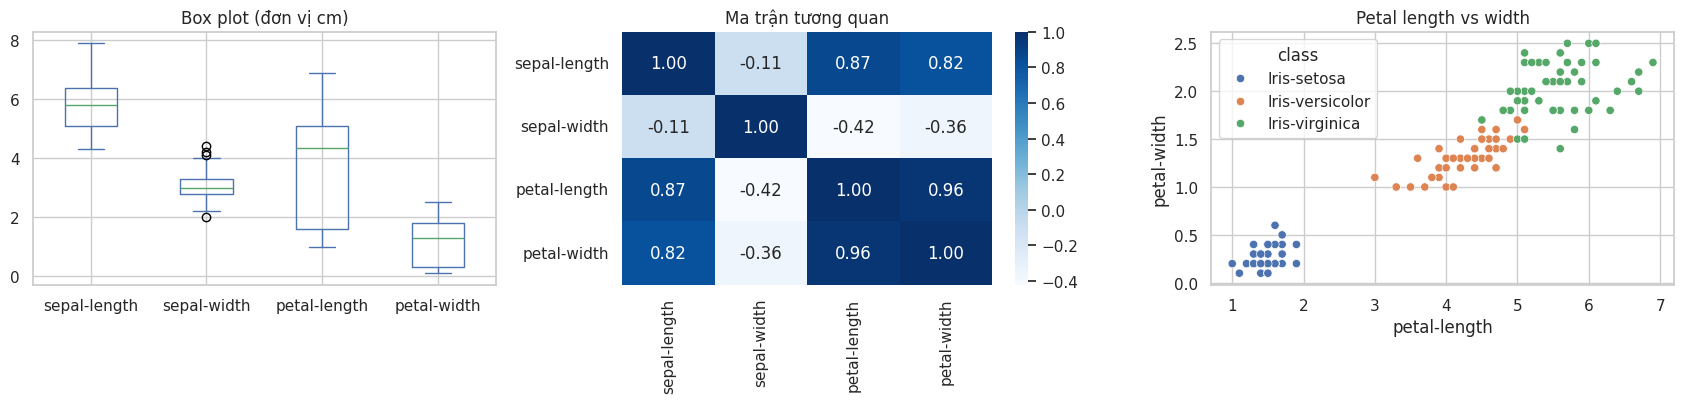

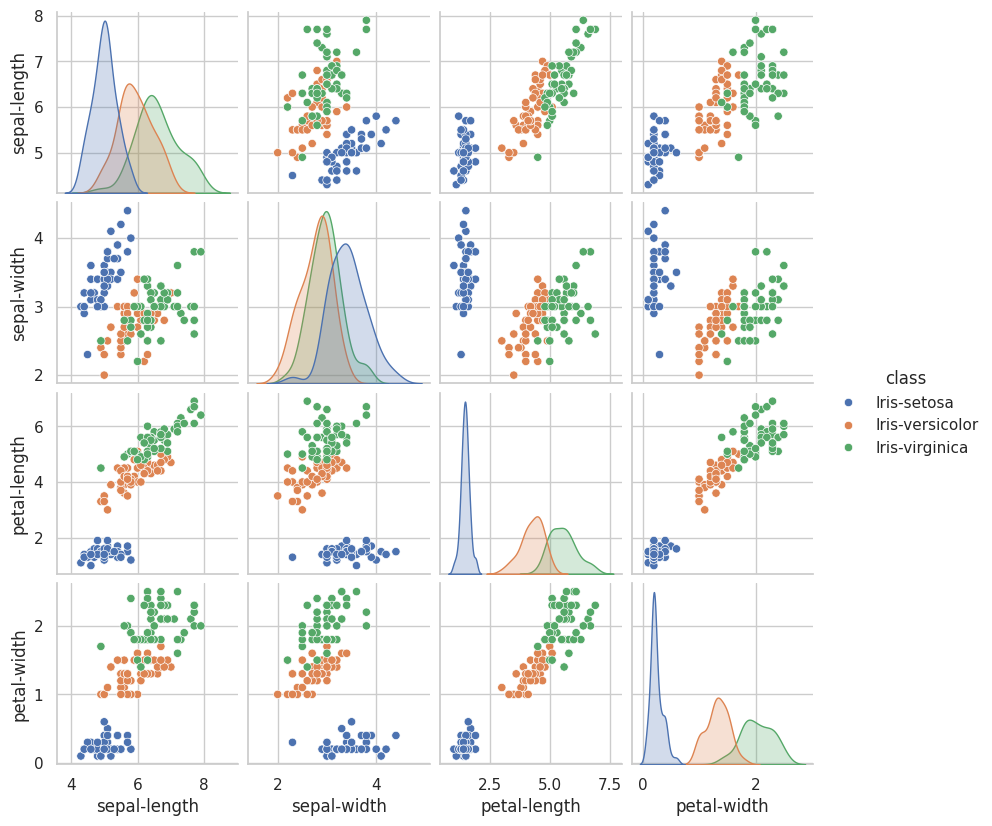

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
df.drop(columns="class").plot(kind="box", ax=ax[0]); ax[0].set_title("Box plot (đơn vị cm)")
sns.heatmap(df.drop(columns="class").corr(), annot=True, fmt=".2f", cmap="Blues", ax=ax[1]); ax[1].set_title("Ma trận tương quan")
sns.scatterplot(data=df, x="petal-length", y="petal-width", hue="class", ax=ax[2]); ax[2].set_title("Petal length vs width")
plt.tight_layout(); plt.show()
sns.pairplot(df, hue="class", height=2.1); plt.show()

**Nhận xét**
- Không có giá trị thiếu; có vài dòng trùng (dữ liệu đo thật nên trùng là bình thường, tác động nhỏ).
- `petal-length` và `petal-width` tương quan rất cao (~0.96) → thông tin lặp lại; 2 đặc trưng *petal* phân tách lớp tốt nhất.
- **Setosa tách rời hoàn toàn** khỏi hai loài còn lại; *versicolor* và *virginica* chồng lấn nhẹ ở vùng biên → đây là nơi mô hình sẽ nhầm lẫn.
- Bốn đặc trưng cùng đơn vị nhưng khác độ trải (std) → chuẩn hóa vẫn có thể ảnh hưởng tới KNN/SVM.

## 3. Chuẩn bị dữ liệu
- Mã hóa nhãn bằng `LabelEncoder`.
- Chia **hold-out 80/20 có phân tầng (stratify)** → 120 train / 30 test . Test chỉ dùng **một lần** ở cuối.
- **Scaler đặt trong Pipeline** để mỗi fold CV chỉ học thống kê từ phần train của fold đó (không rò rỉ).

In [5]:
le = LabelEncoder(); y = le.fit_transform(df["class"]); X = df.drop(columns="class").values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print("train", X_tr.shape, np.bincount(y_tr), "| test", X_te.shape, np.bincount(y_te), "| classes:", list(le.classes_))

train (120, 4) [40 40 40] | test (30, 4) [10 10 10] | classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 4. Đánh giá thuật toán (Spot-check)


,MinMax,Raw,Standard
CART,0.9317,0.9317,0.9317
KNN,0.9467,0.9383,0.9333
LDA,0.9750,0.9750,0.9750
LR,0.9217,0.9533,0.9417
NB,0.9450,0.9450,0.9450
SVM,0.9483,0.9550,0.9400


Độ lệch chuẩn (CV):


,MinMax,Raw,Standard
CART,0.0570,0.0570,0.0570
KNN,0.0572,0.0641,0.0667
LDA,0.0382,0.0382,0.0382
LR,0.0753,0.0504,0.0583
NB,0.0592,0.0592,0.0592
SVM,0.0550,0.0506,0.0578


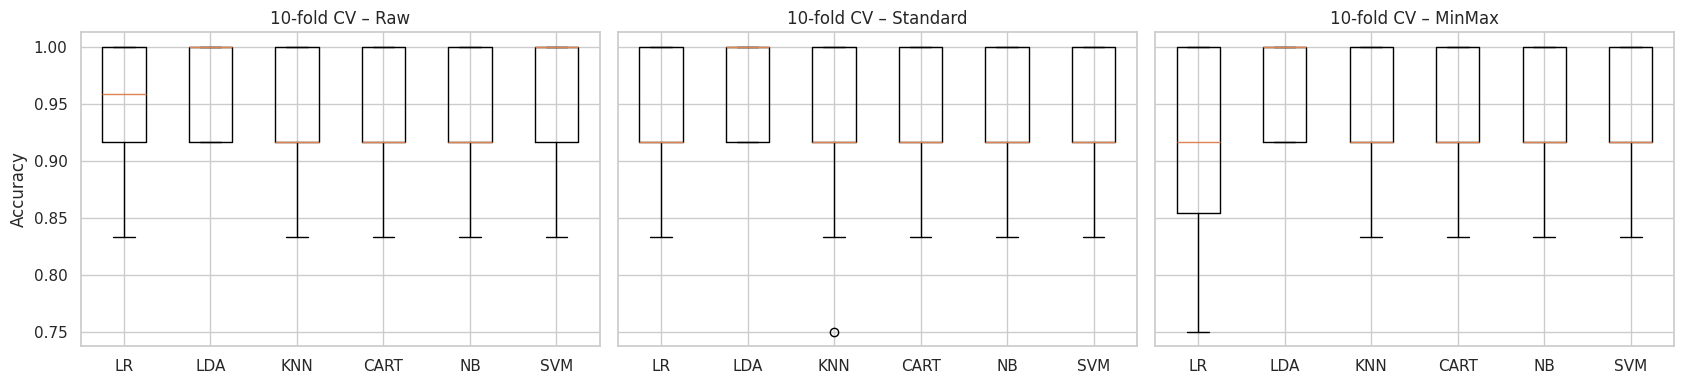

In [6]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=SEED)
models = {"LR":LogisticRegression(max_iter=1000), "LDA":LinearDiscriminantAnalysis(), "KNN":KNeighborsClassifier(),
          "CART":DecisionTreeClassifier(random_state=SEED), "NB":GaussianNB(), "SVM":SVC()}
scalers = {"Raw":None, "Standard":StandardScaler(), "MinMax":MinMaxScaler()}
def pipe(m, sc): return Pipeline(([("sc", sc)] if sc is not None else []) + [("clf", m)])
res = {(n,s): cross_val_score(pipe(m, sc), X_tr, y_tr, cv=cv, scoring="accuracy", n_jobs=-1) for n,m in models.items() for s,sc in scalers.items()}
tab = pd.Series({k:v.mean() for k,v in res.items()}).unstack().round(4)
display(tab)
print("Độ lệch chuẩn (CV):"); display(pd.Series({k:v.std() for k,v in res.items()}).unstack().round(4))
fig, ax = plt.subplots(1,3, figsize=(17,4), sharey=True)
for a,s in zip(ax, scalers): a.boxplot([res[(n,s)] for n in models], labels=list(models)); a.set_title(f"10-fold CV – {s}")
ax[0].set_ylabel("Accuracy"); plt.tight_layout(); plt.show()

**Nhận xét**: mọi thuật toán đạt ~92–97.5%. **LDA dẫn đầu (~97.5%)**, các mô hình còn lại dao động 92–95.5%. Tác động của scaling **nhỏ và không nhất quán** (< 3%, trong khi độ lệch chuẩn giữa các fold là ~4–7%) nên không thể kết luận cách scale nào tốt hơn; riêng CART, NB, LDA hoàn toàn không đổi vì bất biến với phép biến đổi tuyến tính từng đặc trưng. Kết quả tốt của LDA hợp lý vì các lớp gần như tách tuyến tính.

## 5. Cải thiện kết quả

In [7]:
cv5 = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
grids = {"KNN":(KNeighborsClassifier(), {"clf__n_neighbors":list(range(1,22,2)), "clf__weights":["uniform","distance"]}),
         "SVM":(SVC(), {"clf__C":[0.1,0.5,1,2,5,10,50], "clf__kernel":["linear","rbf"], "clf__gamma":["scale",0.05,0.2,1]}),
         "LR": (LogisticRegression(max_iter=2000), {"clf__C":[0.1,0.3,1,3,10,30]})}
tuned = {}
for n,(m,g) in grids.items():
    gs = GridSearchCV(pipe(m, StandardScaler()), g, cv=cv5, scoring="accuracy", n_jobs=-1).fit(X_tr, y_tr)
    tuned[n] = gs.best_estimator_; print(f"{n:4s} best CV={gs.best_score_:.4f}  {gs.best_params_}")

KNN  best CV=0.9667  {'clf__n_neighbors': 11, 'clf__weights': 'distance'}


SVM  best CV=0.9750  {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
LR   best CV=0.9750  {'clf__C': 10}


In [8]:
ens = {"RF":RandomForestClassifier(n_estimators=300, random_state=SEED), "ET":ExtraTreesClassifier(n_estimators=300, random_state=SEED),
       "GBM":GradientBoostingClassifier(random_state=SEED), "AdaBoost":AdaBoostClassifier(n_estimators=100, random_state=SEED)}
ens_res = {n: cross_val_score(m, X_tr, y_tr, cv=cv, n_jobs=-1) for n,m in ens.items()}
vote = VotingClassifier([("lda",LinearDiscriminantAnalysis()),("svm",SVC(probability=True, random_state=SEED)),("knn",KNeighborsClassifier(9)),("lr",LogisticRegression(max_iter=1000))], voting="soft")
ens_res["Voting(LDA+SVM+KNN+LR)"] = cross_val_score(pipe(vote, StandardScaler()), X_tr, y_tr, cv=cv, n_jobs=-1)
for n in tuned: ens_res[f"{n} (tuned)"] = cross_val_score(tuned[n], X_tr, y_tr, cv=cv, n_jobs=-1)
ens_res["LDA (baseline)"] = res[("LDA","Standard")]
t2 = pd.DataFrame({k:(v.mean(), v.std()) for k,v in ens_res.items()}, index=["mean","std"]).T.sort_values("mean", ascending=False).round(4)
display(t2)

,mean,std
LDA (baseline),0.9750,0.0382
LR (tuned),0.9733,0.0423
Voting(LDA+SVM+KNN+LR),0.9617,0.0448
SVM (tuned),0.9617,0.0533
KNN (tuned),0.9517,0.0502
GBM,0.9450,0.0568
ET,0.9417,0.0583
RF,0.9350,0.0630
AdaBoost,0.9233,0.0663


Nhóm đầu (LDA 97.5%, LR-tuned 97.3%, SVM/Voting ~96%) chênh nhau chỉ ~1–2%, **nhỏ hơn độ lệch chuẩn của CV (~4–5%)**. Các ensemble (RF, GBM, AdaBoost) **không** vượt được mô hình tuyến tính đơn giản – điều thường gặp với dữ liệu nhỏ, sạch và gần tuyến tính. Ta chọn **LDA**: dẫn đầu CV *và* đơn giản nhất (nguyên tắc Occam). Lưu ý: chọn dựa trên CV, không dựa trên tập test.

## 6. Trình bày kết quả

Test accuracy = 1.0000  (30/30 đúng)
Lưu ý: test chỉ có 30 mẫu, sai 1 mẫu đã mất 3.3% -> con số này có sai số lớn; ước lượng đáng tin hơn là CV (~97%).

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



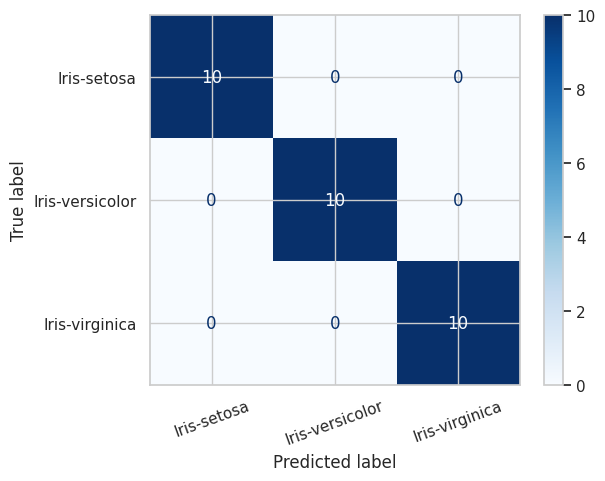

In [9]:
final = pipe(LinearDiscriminantAnalysis(), StandardScaler()).fit(X_tr, y_tr)   # mô hình chọn theo CV: LDA
pred = final.predict(X_te)
print(f"Test accuracy = {accuracy_score(y_te, pred):.4f}  ({int((pred==y_te).sum())}/{len(y_te)} đúng)")
print("Lưu ý: test chỉ có 30 mẫu, sai 1 mẫu đã mất 3.3% -> con số này có sai số lớn; ước lượng đáng tin hơn là CV (~97%).\n")
print(classification_report(y_te, pred, target_names=le.classes_))
ConfusionMatrixDisplay(confusion_matrix(y_te, pred), display_labels=le.classes_).plot(cmap="Blues", xticks_rotation=20); plt.show()

In [10]:
# Lưu mô hình + bộ mã hóa nhãn, rồi nạp lại để dự đoán mẫu mới
final_all = pipe(LinearDiscriminantAnalysis(), StandardScaler()).fit(X, y)                       # huấn luyện lại trên toàn bộ 150 mẫu
joblib.dump({"model":final_all, "label_encoder":le, "features":names[:-1]}, "iris_final_model.joblib")
bundle = joblib.load("iris_final_model.joblib")
new = pd.DataFrame([[5.0,3.4,1.5,0.2],[6.1,2.9,4.6,1.4],[7.2,3.0,5.9,2.1]], columns=bundle["features"])
new["dự đoán"] = bundle["label_encoder"].inverse_transform(bundle["model"].predict(new.values))
display(new)

,sepal-length,sepal-width,petal-length,petal-width,dự đoán
0,5.0,3.4,1.5,0.2,Iris-setosa
1,6.1,2.9,4.6,1.4,Iris-versicolor
2,7.2,3.0,5.9,2.1,Iris-virginica
